In [50]:
import kagglehub
import pandas as pd
import os

In [ ]:
# Download latest version
path = kagglehub.dataset_download("snap/amazon-fine-food-reviews")

df = pd.read_csv(os.path.join(path, "Reviews.csv"))
df.info()

,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text
0,1,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,5,1303862400,Good Quality Dog Food,I have bought several of the Vitality canned d...
1,2,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,1,1346976000,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...
2,3,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1,1,4,1219017600,"""Delight"" says it all",This is a confection that has been around a fe...
3,4,B000UA0QIQ,A395BORC6FGVXV,Karl,3,3,2,1307923200,Cough Medicine,If you are looking for the secret ingredient i...
4,5,B006K2ZZ7K,A1UQRSCLF8GW1T,"Michael D. Bigham ""M. Wassir""",0,0,5,1350777600,Great taffy,Great taffy at a great price. There was a wid...


Low score rate: 14.43%
Medium score rate: 7.50%
High score rate: 78.07%


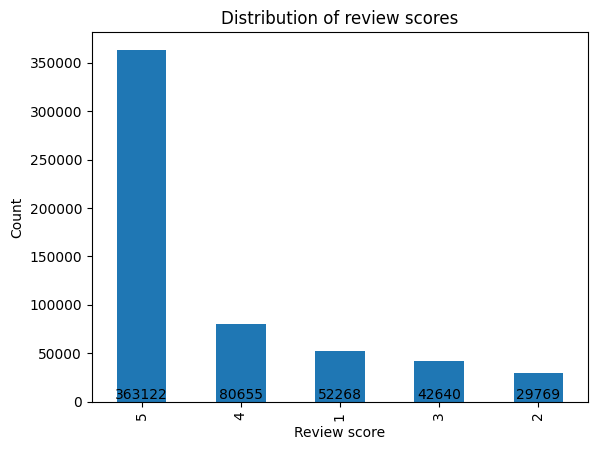

In [52]:
# EDA = Exploratory Data Analysis
# - Distribution of review scores
# - Decision to use Categories weights

low_score = (df["Score"] < 3).sum()
medium_score = (df["Score"] == 3).sum()
high_score = (df["Score"] > 3).sum()
total = df.shape[0]

print(f"Low score rate: {low_score / total * 100:.2f}%")
print(f"Medium score rate: {medium_score / total * 100:.2f}%")
print(f"High score rate: {high_score / total * 100:.2f}%")

plot = df.value_counts("Score").plot(kind="bar")
plot.set_title("Distribution of review scores")
plot.set_xlabel("Review score")
plot.set_ylabel("Count")

for bar in plot.patches:
    plot.text(bar.get_x() + bar.get_width() / 2, 0.0, f"{bar.get_height()}", ha="center", va="bottom")

Text(0, 0.5, 'Count')

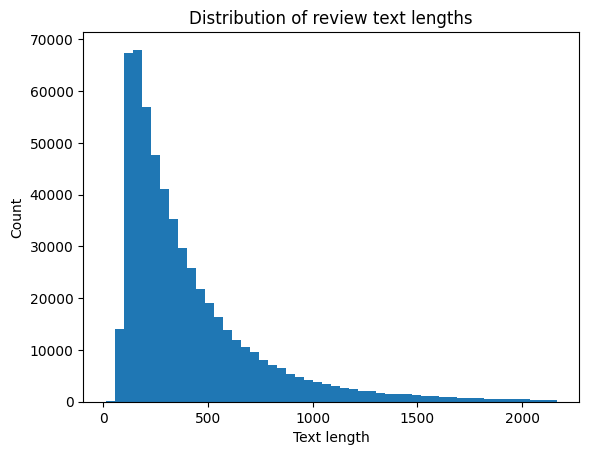

In [53]:
# Histograme de la longuer des textes
# Il y a des valeurs extrèmes que l'on va exclure de l'analyse
# Si on n'extrait pas les données extrèmes avant, le nombre de bins est calculé sur l'intégralité du dataset
data = df["Text"].str.len()[df["Text"].str.len() < df["Text"].str.len().quantile(0.99)]

plot = data.plot(kind="hist", bins=50)
plot.set_title("Distribution of review text lengths")
plot.set_xlabel("Text length")
plot.set_ylabel("Count")

In [54]:
# Afficher le texte le plus long
longest_text = df.loc[df["Text"].str.len().idxmax(), "Text"]
print("Longest review text:")
print(longest_text)

Longest review text:
Fuzzy Wuzzy's Summary:<br />*** Somewhat recommended, with reservations and only lukewarm fuzzies.<br /><br />Positives:<br /><br />+ Not too expensive compared to other bottled water, although it is not cheap either.<br /><br />Negatives:<br /><br />- This bottled water product's labeling, product descriptions, and health claims are misleading.<br /><br />At first glance, this 1.5-liter bottle of water that I am reviewing looks like another one of the many varieties of bottled water on the market.  There are many kinds of bottled water: "spring water" produced from an underground formation where the groundwater naturally flows up to the Earth's surface, "artesian water" obtained from a well that taps into an underground aquifer, "mineral water" produced from a well or spring that naturally contains trace amounts of minerals that some people consider to provide health benefits, "ground/well water" produced from a well that tapes into an aquifer, "sparkling water" f

In [56]:
# Afficher 5 exemple par classe
print ("Examples of high score reviews:")
print(df[df["Score"] > 3]["Text"].sample(5, random_state=42).values)

print("\nExamples of medium score reviews:")
print(df[df["Score"] == 3]["Text"].sample(5, random_state=42).values)

print("\nExamples of low score reviews:")
print(df[df["Score"] < 3]["Text"].sample(5, random_state=42).values)

Examples of high score reviews:
["I have started every morning for the last 7 months with a cup of Ganocafe Classic coffee. In my opinion it must be providing some benefits, I haven't had even one cold or any flu in that time. At age 71 years my blood pressure is lower than my doctor's nurse. I actually generally just feel better all around than I have in years. A daily 1 mile walk and an hour exercising in the pool could have some bearing on my general health. I recommend trying Ganocafe Classic, you will probably see a difference."
 "Thank goodness this pasta makes life for a gluten-free lifestyle so much more enjoyable.  It cooks with enough firm texture, unlike other gluten-free items that become too soggy or a mush.  The pasta goes well in Greek tomato-based dishes, in a pasta dish with only olive oil, sardines, garlic, and chili pepper flakes, as well as in casseroles and normal pasta dishes.  I'm glad I bought the five box package too."
 'I am the type of person who gets tired a